
# Przygotowanie

Przygotowanie
Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko. {nr_albumu}_{imię}_{nazwisko}_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę TEAMS.

# Support Vector Machine

Jest to jeden z najbardziej rozpowszechnionych i wszechstronnych modeli uczenia maszynowego. Z jego uzyciem dokonac mozna klasyfikacji liniowej (SVC), nieliniowej jak i regresji (SVR). Na poniższej grafice przedstawione zostało działanie klasyfikatora.

![svc](svc.png)

Analizujac grafike dostrzec mozna dwie oddzielne klasy oddzielone za pomoca prostej. Widoczna linia ciagła rozdziela klasy, a przerywane linie oznaczają margines, czyli możliwe najdalsze oddalenie elementu (np. nowego) jaki zakwalifikowany
zostanie do danej klasy. Maszyny SVM czułe sa na skale danych, przed ich uzyciem zawsze powinna zostać przeprowadzona normalizacja danych (np. min-max, lub standaryzacja).

![svc_example](svc2.jpg)

Równowage pomiedzy marginesami możemy regulować za pomoca hipermarapetru
C. Mniejsze jego wartości poszerzają granice, jednocześnie wprowadzając
więcej jej naruszeń. Im margines jest szerszy, tym własciwosci generalizujace
jakie posiada klasyfikator będę większe. Mniejsza staje się podatność na przeuczenie
(ang. overfitting), ale zmniejsza się skuteczność klasyfikatora. Szukany jest
taki klasyfikator, który podzieli przestrzeń na dwa rozłaczne zbiory odpowiadajace
dwóm klasom, w możliwie optymalny sposób. Podejście opiera się na
znalezieniu granicy decyzyjnej.

Wektory nośne (Support vectors) są to obserwacje (data points), które wystepują najbliżej hiperpłaszczyzny. Punkty te, pomagają lepiej wyznaczyć linię separacji pomiędzy klasami poprzez obliczenie marginesów. Są to najbardziej znaczace obserwacje ze zbioru z punktu widzenia konstrukcji klasyfikatora.

Warto zaznaczyć, że za pomocą klasyfikatora SVC można klasyfikaować dane, które nie są linowo separowalne. Można to osiągnąć przez tzw "sztuczkę kernelową", dzięki czemu możliwe jest zmapowanie obserwacji do wielowymiarowej przestrzeni. Klasyfikator z biblioteki Sklearn posiada parametr *kernel*, który pozwala na zmianę jądra. Dodatkowo, parametr *gamma* pozwala na modyfikację działania samego kernela.

Warto zaznaczyć, że SVC dobrze nadaje się do niewielkich zbiorów danych, gdyż w przypadku dużej ilości staję się on mało wydajny.

Funkcja jaka jest minimalizowana podczas działania klasyfikatora wygląda następująco:

\begin{equation}
min C \sum^m_{i=1}[y^{(i)}cost_{1}(\theta^{T}x^{(i)}) - (1 - y^{(i)})cost_{0}(\theta^{T}x^{(i)})] + \frac{1}{2} \sum^{n}_{i=1}\theta^{2}_{j}
\end{equation}

## Zadanie 0 

Wczytanie danych ze zbioru oraz wizualizacja.

In [1]:
import pandas as pd

data_input = pd.read_csv('./Ankieta.csv')
data_input.head()

,Waga,Wzrost,Plec
0,55,160,Kobieta
1,78,180,Mezczyzna
2,55,150,Kobieta
3,99,196,Mezczyzna
4,90,180,Mezczyzna


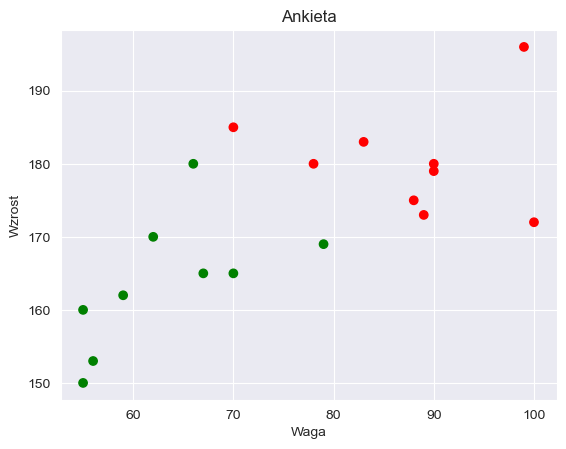

In [2]:
import matplotlib.pyplot as plt
from matplotlib import colors

x = data_input['Plec'].map(lambda x: 1 if x == 'Kobieta' else 0)
y = data_input['Waga']
z = data_input['Wzrost']

data_input['Plec'] = data_input['Plec'].map(lambda x: 1 if x == 'Kobieta' else 0)

plt.scatter(y, z, c=x, cmap=colors.ListedColormap(['red', 'green']))
plt.xlabel('Waga')
plt.ylabel('Wzrost')
plt.title('Ankieta')
plt.show()

/var/folders/bb/m3bx4_9533n3h0xhv96spdv40000gn/T/ipykernel_69375/3623767017.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data_input.hist(ax=ax)


array([[<Axes: title={'center': 'Waga'}>,
        <Axes: title={'center': 'Wzrost'}>],
       [<Axes: title={'center': 'Plec'}>, <Axes: >]], dtype=object)

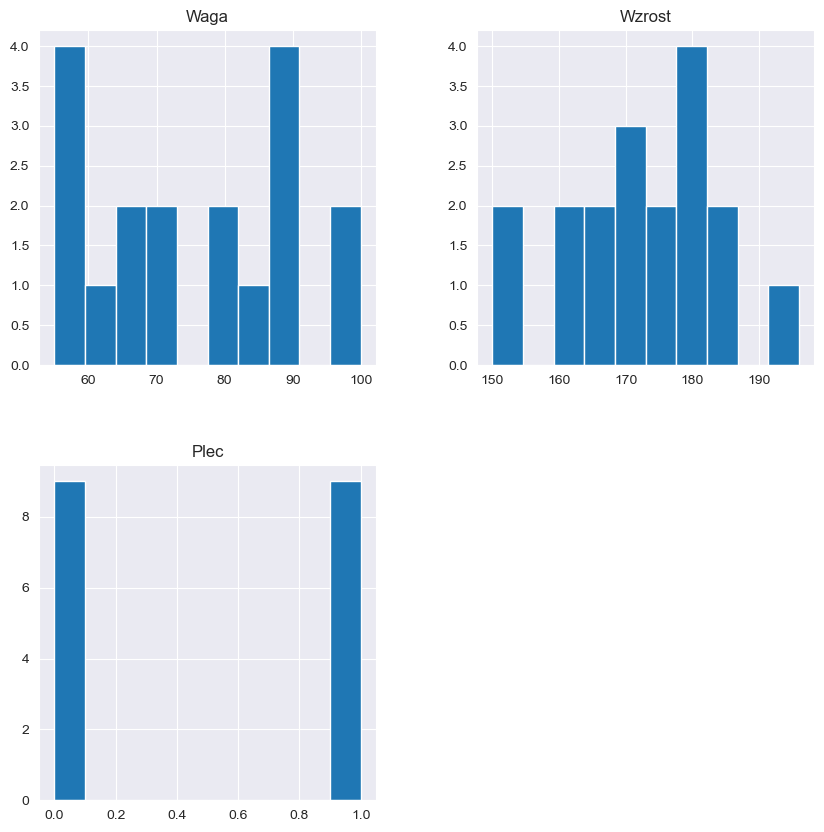

In [3]:
fig = plt.figure(figsize=(10, 10))
ax = fig.gca()
data_input.hist(ax=ax)

<Axes: >

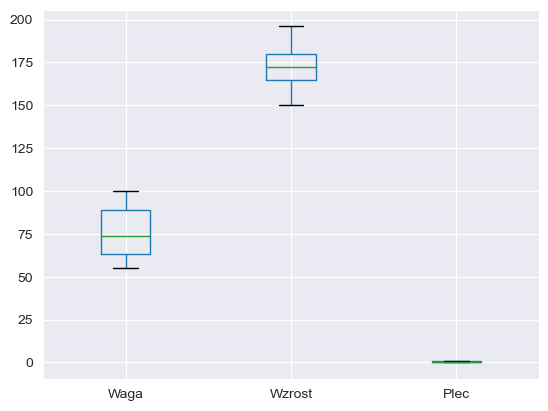

In [4]:
data_input.boxplot()

Na bazie wykresów box-plot można stwierdzić, że dane posiadają różniące się zakresy, co powoduje potrzebę ich skalowania. Warto zauważyć również, że rozkład klas w zbiorze jest równomierny (patrz: histogram)

## Zadanie 1

Proszę dokonać normalizacji zbioru danych za pomocą standaryzacji oraz narysować wykres box-plot dla wszystkich zmiennych. W jaki sposób zmieniły się dane? Co można powiedzieć o ich zakresach. W jakim celu dokonujemy normalizacji?

In [5]:
from sklearn.preprocessing import StandardScaler

X = data_input[['Wzrost', 'Waga']].values
y = data_input['Plec'].values

data_input[['Wzrost_stand', 'Waga_stand']] = StandardScaler().fit_transform(X)

<Axes: >

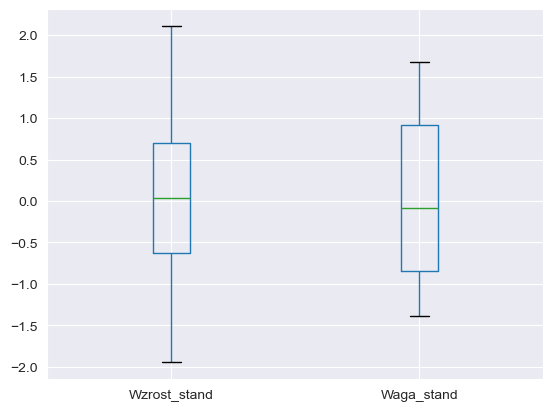

In [6]:
data_input[['Wzrost_stand', 'Waga_stand']].boxplot()

In [7]:
data_input.describe()

,Waga,Wzrost,Plec,Wzrost_stand,Waga_stand
count,18.000000,18.000000,18.000000,1.800000e+01,1.800000e+01
mean,75.333333,172.055556,0.500000,1.147230e-15,3.330669e-16
std,15.115244,11.674367,0.514496,1.028992e+00,1.028992e+00
min,55.000000,150.000000,0.000000,-1.944001e+00,-1.384220e+00
25%,63.000000,165.000000,0.000000,-6.218844e-01,-8.396091e-01
50%,74.000000,172.500000,0.500000,3.917382e-02,-9.076855e-02
75%,88.750000,180.000000,1.000000,7.002320e-01,9.133585e-01
max,100.000000,196.000000,1.000000,2.110490e+00,1.679218e+00


Po standaryzacji zmienne wzrost i waga mają średnią bliską 0 oraz odchylenie standardowe bliskie 1. Zakresy zmiennych stały się porównywalne i nie są już zależne od jednostki miary. Normalizacja minimalizuje dominację cech o większych wartościach oraz wpływa na szybkość uczenia modelu.

## Zadanie 2

W tym zadaniu należy dokonać podziału zbioru danych na uczący oraz testowy. Zbiór uczący będzie służył do treningu klasyfikatora, a testowy do obliczenia ostatecznej skuteczności klasyfikacji. Prosze, by 80% próbek znalazło się w zbiorze uczącym, a 20% w testowym. Proszę zadbać o odpowiednią inicjalizacje generatora pseudolosowego

In [10]:
from sklearn.model_selection import train_test_split

X_stand = data_input[['Wzrost_stand', 'Waga_stand']].values
y_stand = data_input['Plec'].values

X_stand_train, X_stand_test, y_stand_train, y_stand_test = train_test_split(X_stand, y_stand, test_size=0.2, random_state=42, stratify=y)


In [11]:
X = data_input[['Wzrost', 'Waga']].values
y = data_input['Plec'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Zadanie 3

W tym zadaniu należy dokonać klasyfikacji danych za pomocą klasyfikatora SVC. Proszę obliczyć skuteczność klasyfikatora na danych po, oraz przed standaryzacją i porównać wyniki.

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from time import time

start = time()
svc = SVC(kernel='linear', random_state=42)
svc.fit(X_train, y_train)
end = time()
y_pred = svc.predict(X_test)
acc_before_test = accuracy_score(y_test, y_pred) * 100
y_pred = svc.predict(X_train)
acc_before_train = accuracy_score(y_train, y_pred) * 100

print(f'Czas trenowania bez standaryzacji {end - start}')
print(f'Skuteczność bez standaryzacji dane treningowe: {acc_before_train:.2f}%')
print(f'Skuteczność bez standaryzacji dane testowe: {acc_before_test:.2f}%')

Czas trenowania bez standaryzacji 0.0020818710327148438
Skuteczność bez standaryzacji dane treningowe: 100.00%
Skuteczność bez standaryzacji dane testowe: 100.00%


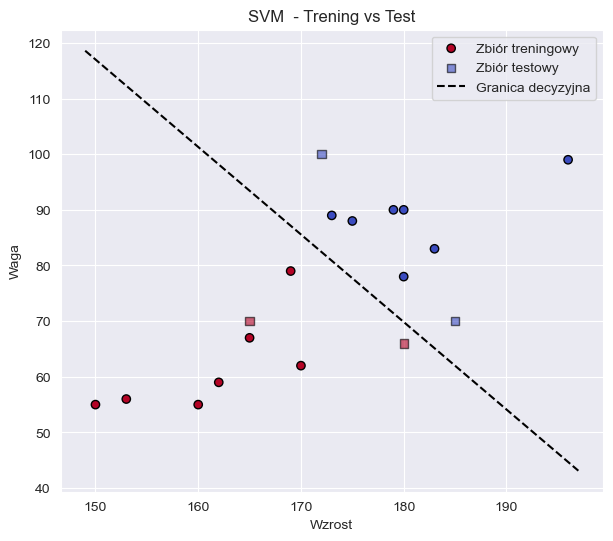

In [13]:
import numpy as np

plt.figure(figsize=(7, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap='coolwarm',
    edgecolor='k',
    label='Zbiór treningowy'
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap='coolwarm',
    edgecolor='k',
    marker='s',
    alpha=0.6,
    label='Zbiór testowy'
)

w = svc.coef_[0]
b = svc.intercept_[0]

x_min = min(X_train[:, 0].min(), X_test[:, 0].min()) - 1
x_max = max(X_train[:, 0].max(), X_test[:, 0].max()) + 1
x_vals = np.linspace(x_min, x_max, 200)

y_vals = -(w[0] * x_vals + b) / w[1]

plt.plot(x_vals, y_vals, 'k--', label='Granica decyzyjna')

plt.title('SVM  - Trening vs Test')
plt.xlabel('Wzrost')
plt.ylabel('Waga')
plt.legend()

In [14]:
start = time()
svc = SVC(kernel='linear', random_state=42)
svc.fit(X_stand_train, y_stand_train)
end = time()
y_pred = svc.predict(X_stand_test)

acc_before_test = accuracy_score(y_stand_test, y_pred) * 100
y_pred = svc.predict(X_stand_train)
acc_before_train = accuracy_score(y_stand_train, y_pred) * 100

print(f'Czas trenowania ze standaryzacja {end - start}')
print(f'Skuteczność ze standaryzacja dane treningowe: {acc_before_train:.2f}%')
print(f'Skuteczność ze standaryzacja dane testowe: {acc_before_test:.2f}%')

Czas trenowania ze standaryzacja 0.0008349418640136719
Skuteczność ze standaryzacja dane treningowe: 100.00%
Skuteczność ze standaryzacja dane testowe: 75.00%


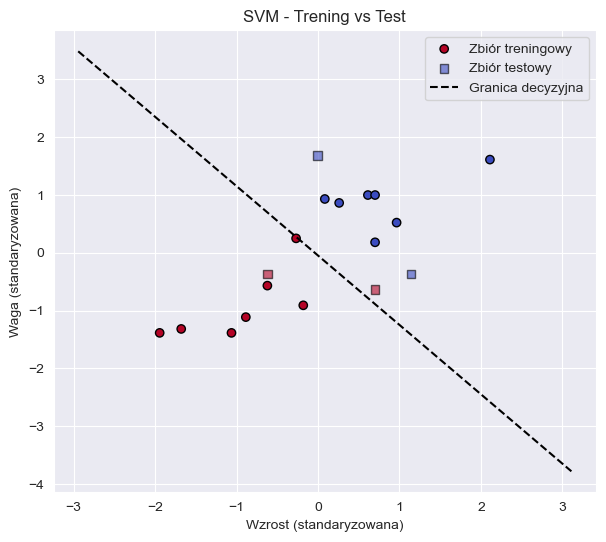

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_stand_train[:, 0],
    X_stand_train[:, 1],
    c=y_stand_train,
    cmap='coolwarm',
    edgecolor='k',
    label='Zbiór treningowy'
)

plt.scatter(
    X_stand_test[:, 0],
    X_stand_test[:, 1],
    c=y_stand_test,
    cmap='coolwarm',
    edgecolor='k',
    marker='s',
    alpha=0.6,
    label='Zbiór testowy'
)

w = svc.coef_[0]
b = svc.intercept_[0]

x_min = min(X_stand_train[:, 0].min(), X_stand_test[:, 0].min()) - 1
x_max = max(X_stand_train[:, 0].max(), X_stand_test[:, 0].max()) + 1
x_vals = np.linspace(x_min, x_max, 200)

y_vals = -(w[0] * x_vals + b) / w[1]

plt.plot(x_vals, y_vals, 'k--', label='Granica decyzyjna')

plt.xlabel('Wzrost (standaryzowana)')
plt.ylabel('Waga (standaryzowana)')
plt.title('SVM - Trening vs Test')
plt.legend()

Klasyfikator SVC liniowy osiągnął 100% skuteczności na danych treningowych zarówno przed, jak i po standaryzacji. Na danych testowych skuteczność spadła po standaryzacji do 75%, standaryzacja mogła wpłynąć na zniekształcenie proporcji, które wcześniej umożliwiały idealną separację liniową. Czas trenowania był nieznacznie krótszy dla danych bez standaryzacji.

## Zadanie 4

Proszę dobrać odpowiedni parametr C (proszę spróbować z zakresu -1, 1 z krokiem co 0.1). Dla każdego C proszę wyrysować hiperpłaszczyznę utworzoną przez klasyfikator (w formie animimacji, lub inaczej). Proszę przedstawić na wykresie jak zmieniała się skuteczność klasyfikatora w zależności od parametru C. Jakie wnioski można wyciągnąć? Jak wpływa parametr C na wynik?

In [16]:
C_values = np.arange(0.1, 4.1, 0.1)
accuracies_train = []
accuracies_test = []
for C in C_values:
    svc = SVC(kernel='linear', C=C, random_state=44)
    svc.fit(X_stand_train, y_stand_train)
    y_pred = svc.predict(X_stand_test)
    acc_test = accuracy_score(y_stand_test, y_pred)
    accuracies_test.append(acc_test)
    y_pred = svc.predict(X_stand_train)
    acc_train = accuracy_score(y_stand_train, y_pred)
    accuracies_train.append(acc_train)

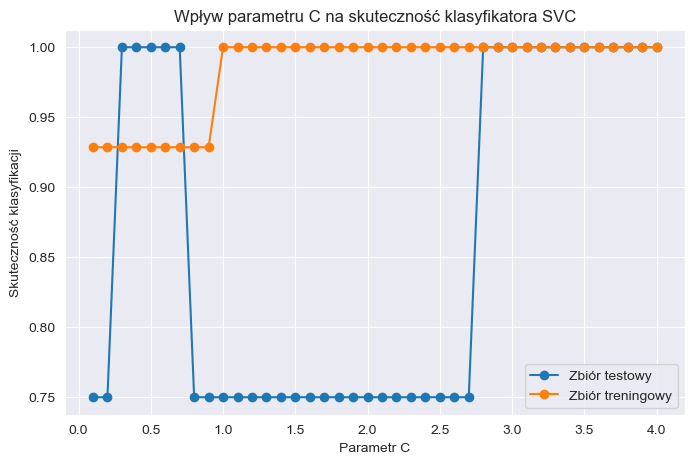

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(C_values, accuracies_test, marker='o', label='Zbiór testowy')
plt.plot(C_values, accuracies_train, marker='o', label='Zbiór treningowy')
plt.xlabel('Parametr C')
plt.ylabel('Skuteczność klasyfikacji')
plt.title('Wpływ parametru C na skuteczność klasyfikatora SVC')
plt.grid(True)
plt.legend()


In [18]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

x_min, x_max = X_stand_train[:, 0].min() - 1, X_stand_train[:, 0].max() + 1
y_min, y_max = X_stand_train[:, 1].min() - 1, X_stand_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)
fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(
    X_stand_train[:, 0],
    X_stand_train[:, 1],
    c=y_train,
    cmap='coolwarm',
    edgecolor='k'
)

plt.scatter(
    X_stand_train[:, 0],
    X_stand_train[:, 1],
    c=y_stand_train,
    cmap='coolwarm',
    edgecolor='k',
    label='Zbiór treningowy'
)

plt.scatter(
    X_stand_test[:, 0],
    X_stand_test[:, 1],
    c=y_stand_test,
    cmap='coolwarm',
    edgecolor='k',
    marker='s',
    alpha=0.6,
    label='Zbiór testowy'
)

contour = None


def update(frame):
    global contour

    C = C_values[frame]

    svc = SVC(kernel='linear', C=C, random_state=44)
    svc.fit(X_stand_train, y_train)

    Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    if contour is not None:
        contour.remove()

    contour = ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap='coolwarm'
    )

    y_pred = svc.predict(X_stand_test)
    acc_test = accuracy_score(y_stand_test, y_pred) * 100
    y_pred = svc.predict(X_stand_train)
    acc_train = accuracy_score(y_stand_train, y_pred) * 100
    ax.set_title(f'SVC  | C = {C:.3f} | Accuracy test = {acc_test:.2f}%  | Accuracy train = {acc_train:.2f}%')


ani = FuncAnimation(
    fig,
    update,
    frames=len(C_values),
    interval=700,
    repeat=True,
    blit=False
)
plt.close(fig)
HTML(ani.to_jshtml())


Jako zakres c wybrano liczby dodatnie, ponieważ tylko takie parametry przyjmuje model. Jak widać na wykresie, wraz ze wzrostem wartości parametru C, skuteczność klasyfikatora na zbiorze treningowym pozostaje wysoka i stabilna, osiągając 100%. Natomiast skuteczność na zbiorze testowym wykazuje pewne fluktuacje, ale generalnie utrzymuje się na wysokim poziomie. Wysoka wartość C powoduje, że klasyfikator stara się minimalizować błędy klasyfikacji, co może prowadzić do nadmiernego dopasowania do danych treningowych. Z kolei niższe wartości C mogą prowadzić do większej elastyczności modelu, co może poprawić jego zdolność generalizacji na nowych danych.

## Zadanie 5

Proszę dokonać pomiaru czasu wykonania algorytmu dla min. 2 różnych kerneli

In [19]:
start = time()
svc = SVC(kernel='linear', random_state=42)
svc.fit(X_stand_train, y_stand_train)
end = time()
print(f'Czas trenowania kernel linear {end - start}')

start = time()
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_stand_train, y_stand_train)
end = time()
print(f'Czas trenowania kernel rbf {end - start}')

start = time()
svc = SVC(kernel='poly', random_state=42)
svc.fit(X_stand_train, y_stand_train)
end = time()
print(f'Czas trenowania kernel poly {end - start}')

start = time()
svc = SVC(kernel='sigmoid', random_state=42)
svc.fit(X_stand_train, y_stand_train)
end = time()
print(f'Czas trenowania kernel sigmoid {end - start}')



Czas trenowania kernel linear 0.0009169578552246094
Czas trenowania kernel rbf 0.0006537437438964844
Czas trenowania kernel poly 0.0006167888641357422
Czas trenowania kernel sigmoid 0.0006079673767089844


Najszybszy czas działania był dla kernel sigmoid, później niewiele dłuższy dla poly i rbf. Najdłuźej liczył się kernel linear.

### Dla zbioru *dataR2* proszę dokonać podobnej analizy danych. Opis zbioru: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Coimbra

## Zadanie 6

Proszę zwizualizować dane dla 2 dowolnych zmiennych ze zbioru

In [20]:
df_r2 = pd.read_csv('dataR2.csv')

In [21]:
df_r2.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [22]:
import seaborn as sns

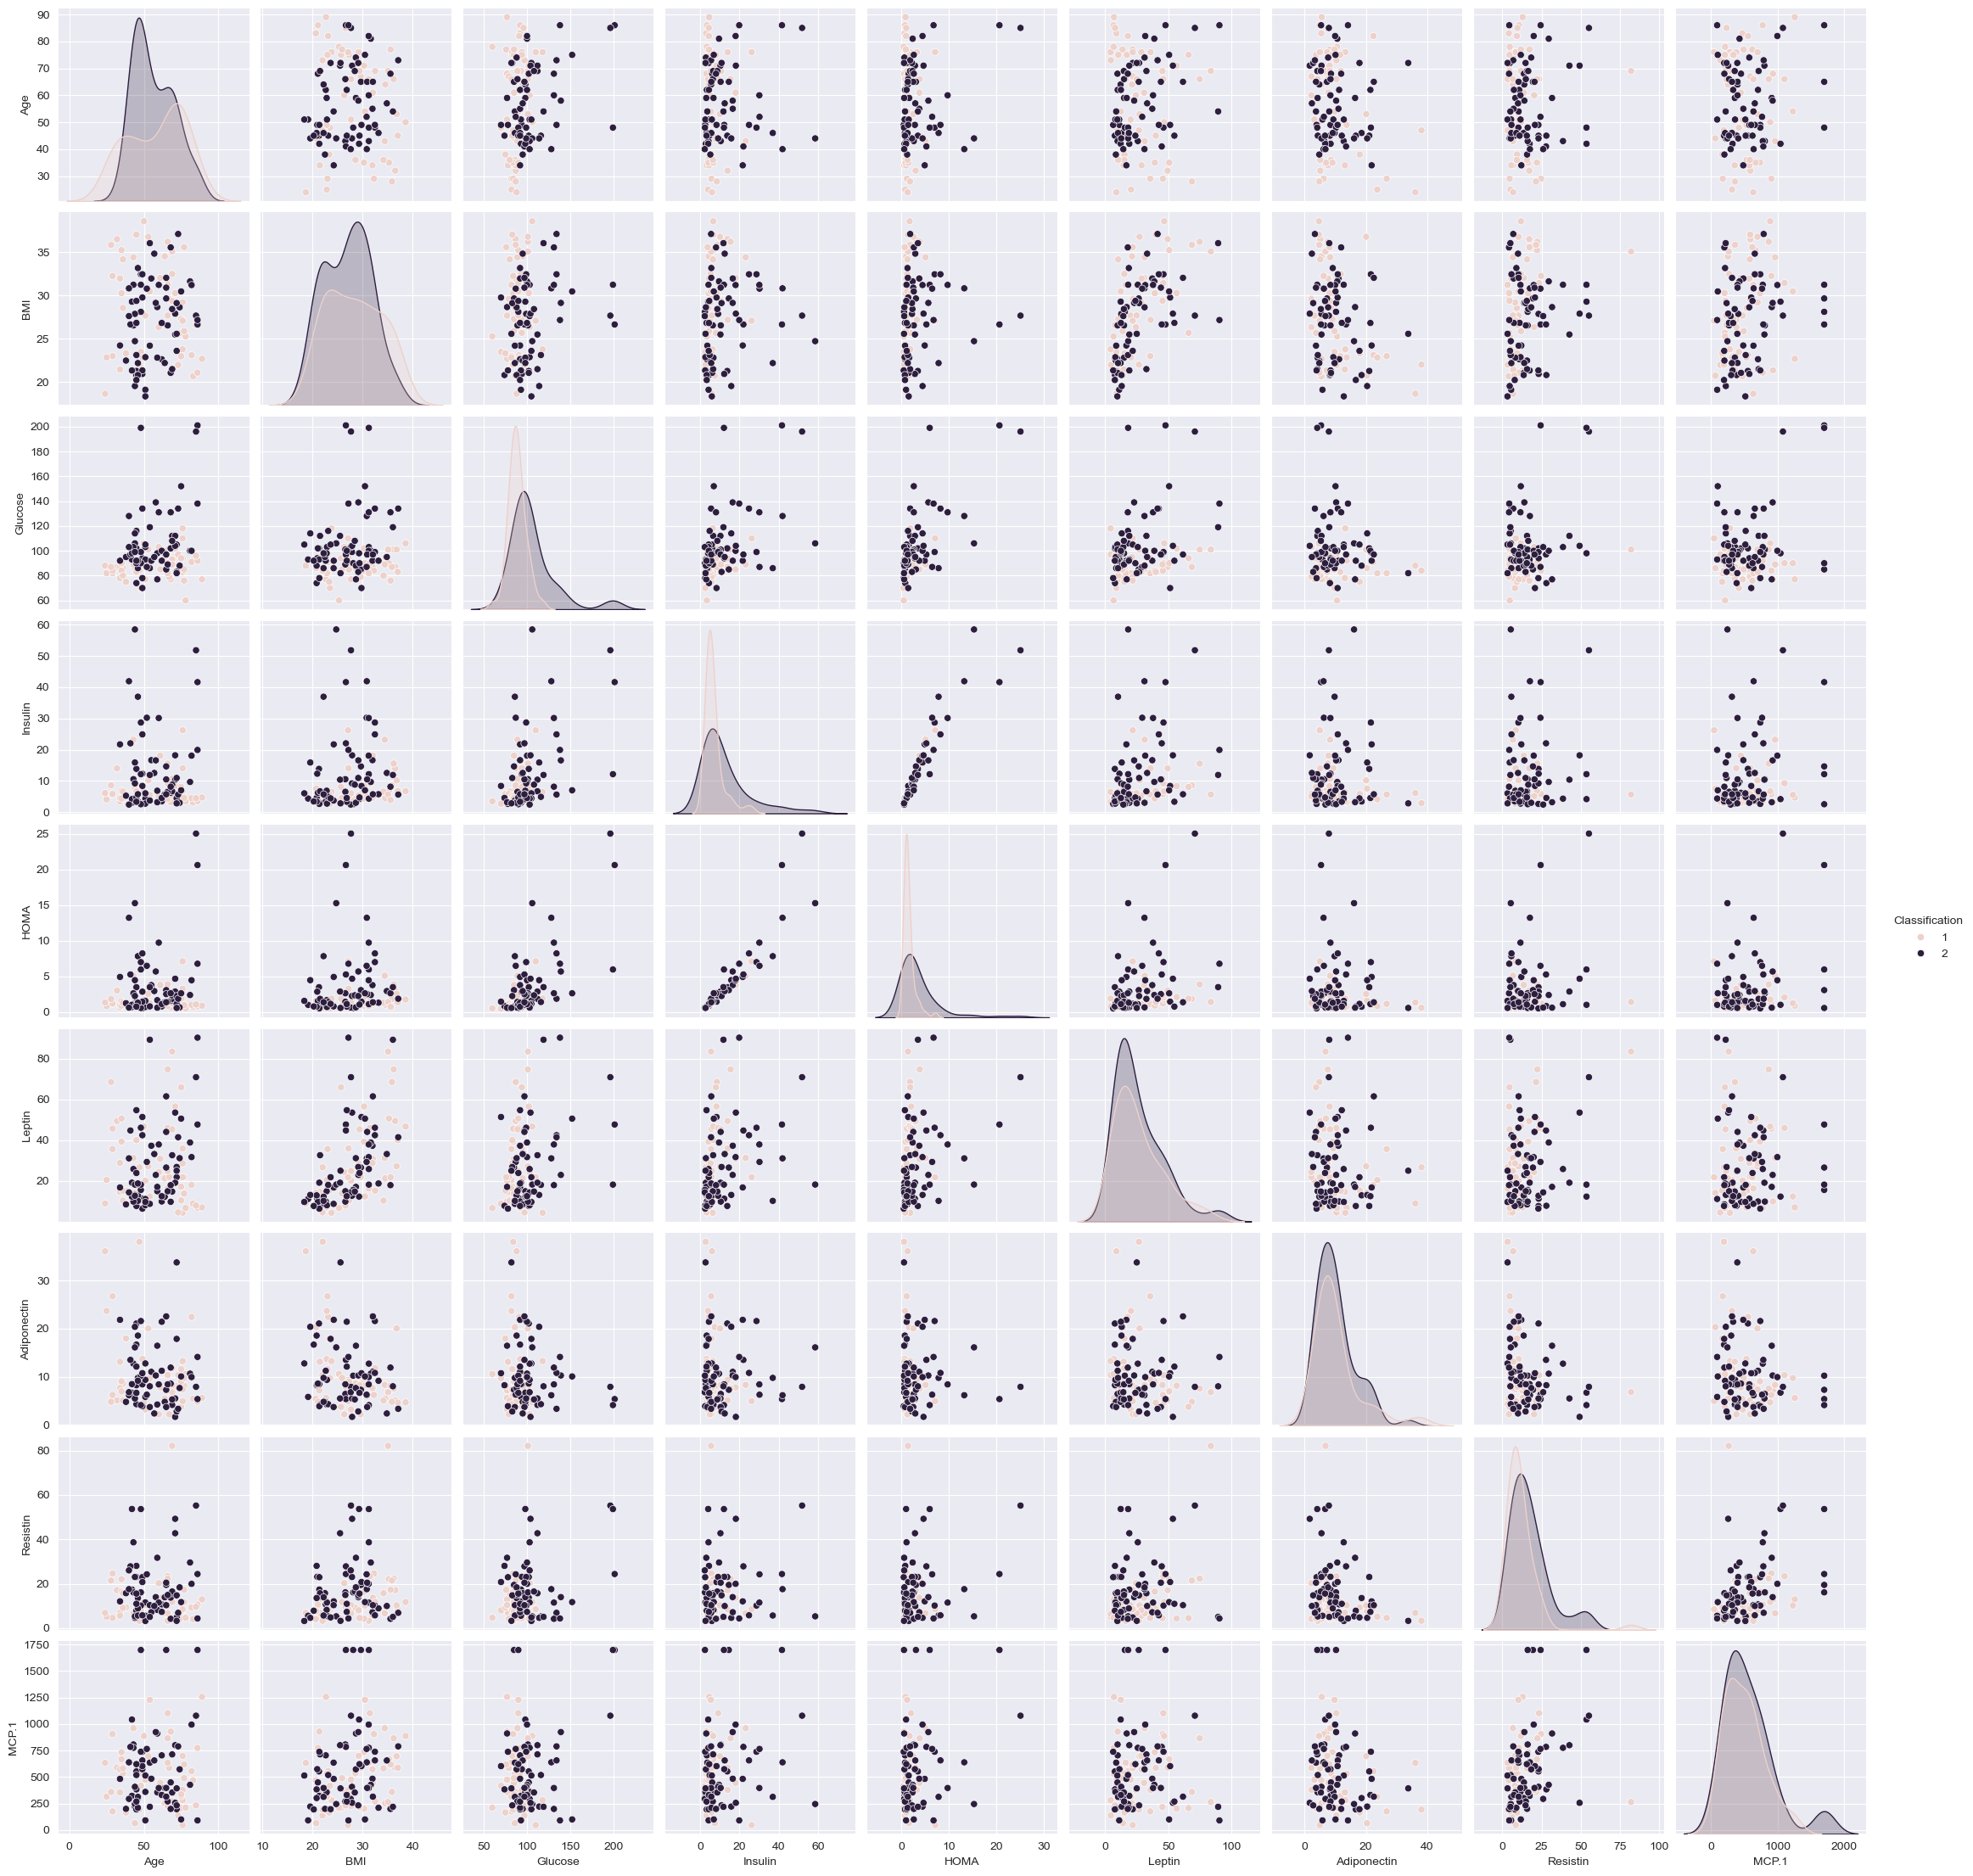

In [23]:
sns.pairplot(df_r2, hue='Classification')

Zadne z dwów zmiennych nie są w łatwy sposób separowalne.

In [24]:
df_r2_selected = df_r2[['Glucose', 'Age', 'Classification']]

In [25]:
df_r2_selected['Classification'].unique()

array([1, 2])

In [26]:
df_r2_selected['Classification'].value_counts()

Classification
2    64
1    52
Name: count, dtype: int64

In [27]:
df_r2_selected['Classification'] = df_r2_selected['Classification'].map({1: 0, 2: 1})

/var/folders/bb/m3bx4_9533n3h0xhv96spdv40000gn/T/ipykernel_69375/2937414545.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_r2_selected['Classification'] = df_r2_selected['Classification'].map({1: 0, 2: 1})


In [28]:
df_r2_selected['Classification'].unique()

array([0, 1])

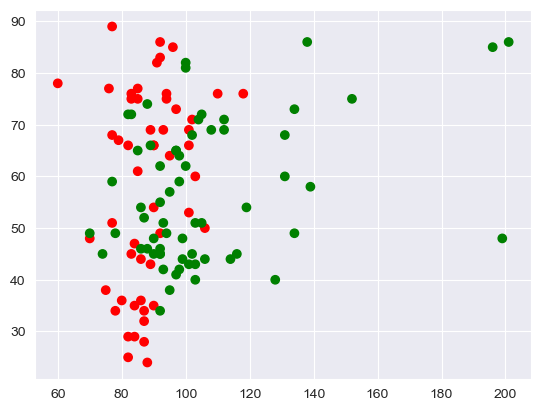

In [29]:
plt.scatter(df_r2_selected['Glucose'], df_r2_selected['Age'], c=df_r2_selected['Classification'],
            cmap=colors.ListedColormap(['red', 'green']))

<Axes: >

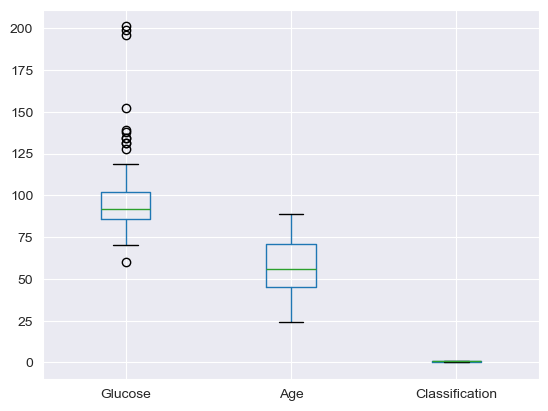

In [30]:
df_r2_selected.boxplot()

## Zadanie 7

Proszę dokonać standaryzacji danych

In [31]:
X = df_r2_selected[['Glucose', 'Age']].values
y = df_r2_selected['Classification'].values

df_r2_selected.loc[:, ['Glucose_stand', 'Age_stand']] = StandardScaler().fit_transform(X)

<Axes: >

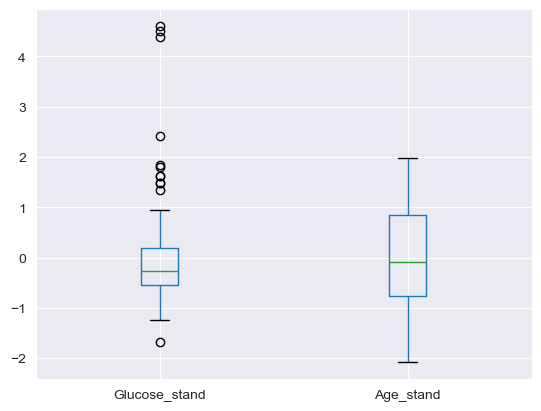

In [32]:
df_r2_selected[['Glucose_stand', 'Age_stand']].boxplot()

## Zadanie 8

Trenowanie klasyfikatora. Proszę dokonać treningu klasyfikatora na zbiorze treningowym (X_train, y_train). Proszę użyć różnych wartości parametru C, gamma oraz kernel. Pełna dokumentacja klasyfikatora: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html Wyniki proszę podsumować na odpowiednim wykresie lub tabeli. Test skuteczności klasyfikatora proszę dokonać na zbiorze testowym (X_test, y_test).

In [33]:
X_stand = df_r2_selected[['Glucose_stand', 'Age_stand']]
y_stand = df_r2_selected['Classification']

X_stand_train, X_stand_test, y_stand_train, y_stand_test = train_test_split(X_stand, y_stand, test_size=0.2,
                                                                            random_state=42, stratify=y)

In [34]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', ]
}

results = []

for params in ParameterGrid(param_grid):
    svc = SVC(C=params['C'],
              gamma=params['gamma'],
              kernel=params['kernel'])
    svc.fit(X_stand_train, y_stand_train)
    y_pred_train = svc.predict(X_stand_train)
    acc_train = accuracy_score(y_stand_train, y_pred_train)
    y_pred_test = svc.predict(X_stand_test)
    acc_test = accuracy_score(y_stand_test, y_pred_test)
    results.append({
        'C': params['C'],
        'gamma': params['gamma'],
        'kernel': params['kernel'],
        'train_accuracy': acc_train,
        'test_accuracy': acc_test,
        'model': svc
    })

results_df = pd.DataFrame(results)

In [35]:
results_df.sort_values(by='test_accuracy', ascending=False)

,C,gamma,kernel,train_accuracy,test_accuracy,model
34,100.0,1,rbf,0.836957,0.791667,"SVC(C=100, gamma=1)"
16,1.0,1,rbf,0.760870,0.791667,"SVC(C=1, gamma=1)"
31,100.0,0.1,rbf,0.771739,0.791667,"SVC(C=100, gamma=0.1)"
22,10.0,0.1,rbf,0.750000,0.791667,"SVC(C=10, gamma=0.1)"
13,1.0,0.1,rbf,0.782609,0.791667,"SVC(C=1, gamma=0.1)"
19,10.0,scale,rbf,0.804348,0.791667,SVC(C=10)
10,1.0,scale,rbf,0.782609,0.791667,SVC(C=1)
25,10.0,1,rbf,0.804348,0.750000,"SVC(C=10, gamma=1)"
28,100.0,scale,rbf,0.793478,0.750000,SVC(C=100)
35,100.0,1,poly,0.760870,0.708333,"SVC(C=100, gamma=1, kernel='poly')"


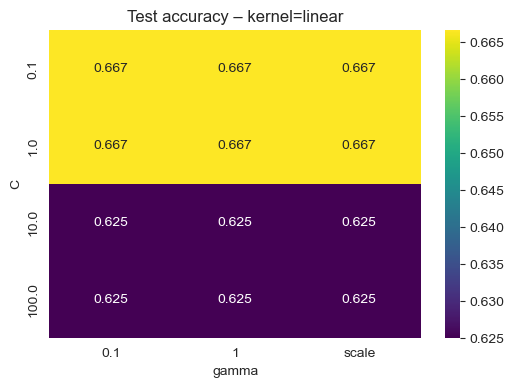

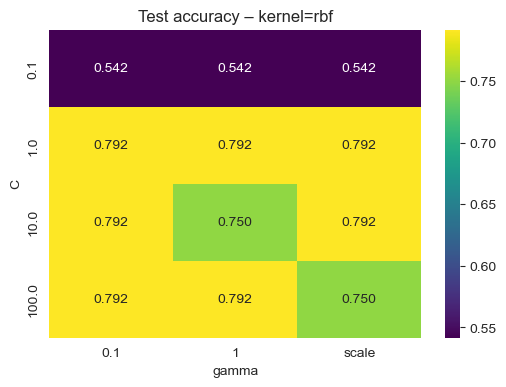

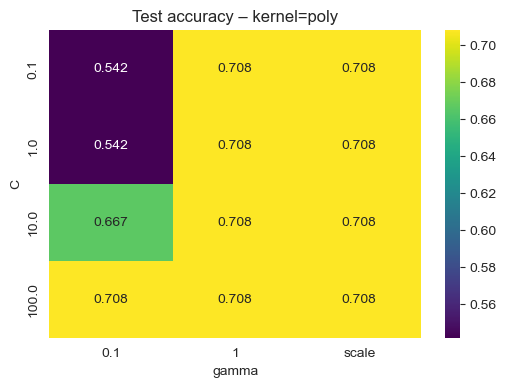

In [36]:
for kernel in results_df['kernel'].unique():
    subset = results_df[results_df['kernel'] == kernel]

    pivot = subset.pivot(
        index='C',
        columns='gamma',
        values='test_accuracy'
    )

    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, cmap='viridis', fmt='.3f')
    plt.title(f'Test accuracy – kernel={kernel}')
    plt.ylabel('C')
    plt.xlabel('gamma')
    plt.show()


Najlepsze wyniki uzyskano dla kernela RBF, który osiąga najwyższą dokładność na zbiorze testowym (~0.79) i jest relatywnie stabilny względem zmian parametrów C i gamma. Kernel liniowy gorzej generalizuj, emimo przyzwoitej dokładności na zbiorze treningowym jego wynik testowy spada, co wskazuje na niedopasowanie do danych. Kernel wielomianowy poprawia dopasowanie treningowe wraz ze wzrostem C, jednak nie przekłada się to na lepszą jakość na zbiorze testowym. Tak jak zauważono na początku, dane nie są liniowo separowalne co przełożyło się na wybór kernela.

## Zadanie 9

Należy wyznaczyć macierze pomyłek dla klasyfikatora. Proszę dokonać wizualizacji wraz z kolorami na wykresie. Przykłady: 

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix

https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html#sphx-glr-auto-examples-model-selection-plot-confusion-matrix-py

In [37]:
results_df.sort_values('test_accuracy', ascending=False).head(9)

,C,gamma,kernel,train_accuracy,test_accuracy,model
34,100.0,1,rbf,0.836957,0.791667,"SVC(C=100, gamma=1)"
16,1.0,1,rbf,0.760870,0.791667,"SVC(C=1, gamma=1)"
31,100.0,0.1,rbf,0.771739,0.791667,"SVC(C=100, gamma=0.1)"
22,10.0,0.1,rbf,0.750000,0.791667,"SVC(C=10, gamma=0.1)"
13,1.0,0.1,rbf,0.782609,0.791667,"SVC(C=1, gamma=0.1)"
19,10.0,scale,rbf,0.804348,0.791667,SVC(C=10)
10,1.0,scale,rbf,0.782609,0.791667,SVC(C=1)
25,10.0,1,rbf,0.804348,0.750000,"SVC(C=10, gamma=1)"
28,100.0,scale,rbf,0.793478,0.750000,SVC(C=100)


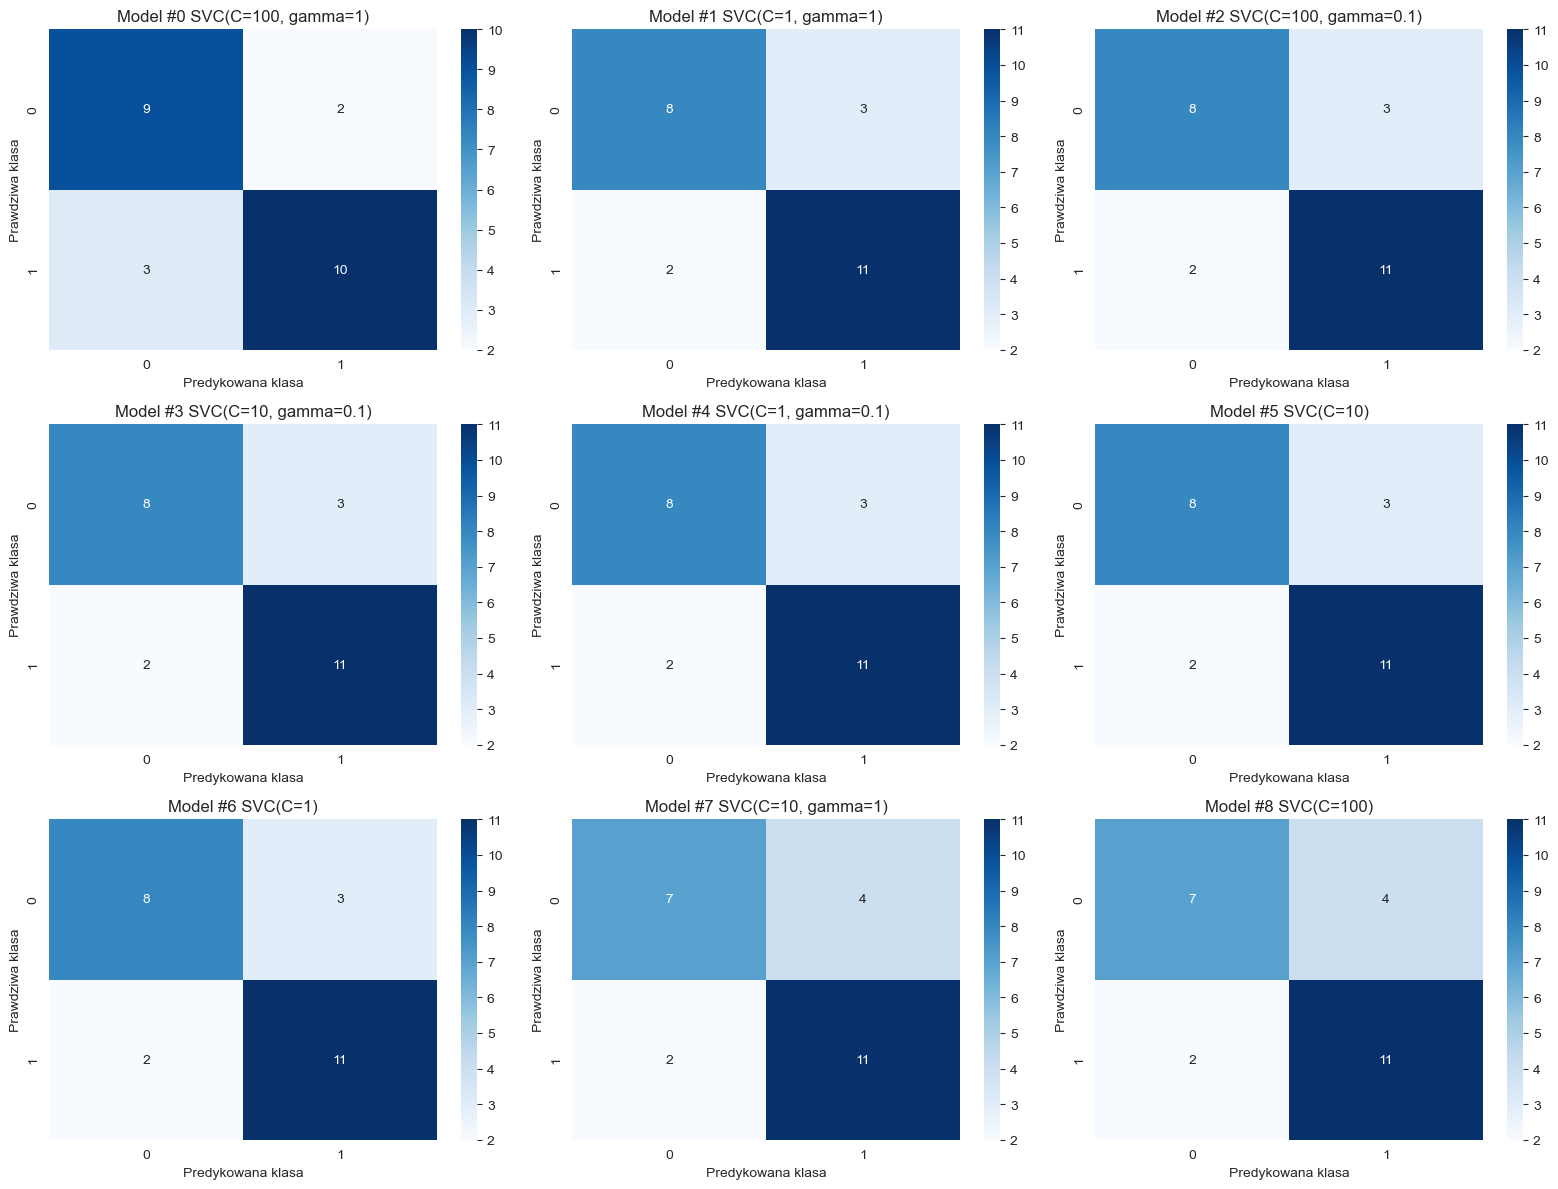

In [38]:
from sklearn.metrics import confusion_matrix

top_n = 9
rows = 3
cols = 3
labels = np.unique(y_test)

fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
results_df = results_df.sort_values(by='test_accuracy', ascending=False)
indexes = results_df.head(top_n).index
for i, idx in enumerate(indexes):
    model = results_df.loc[idx, 'model']
    y_pred = model.predict(X_stand_test)
    cm = confusion_matrix(y_stand_test, y_pred)

    r = i // cols
    c = i % cols
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[r, c])
    axes[r, c].set_title(f'Model #{i} {model}')
    axes[r, c].set_xlabel('Predykowana klasa')
    axes[r, c].set_ylabel('Prawdziwa klasa')




plt.tight_layout()


Dla najlepszych 9 modeli macierze pomyłek wyglądają bardzo podobnie